In [44]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from fredapi import Fred
import itertools
#downloaded all the dependencies

In [2]:
gold = yf.Ticker("GLD")
euro = yf.Ticker("^STOXX50E")
fx = yf.Ticker("JPY=X")
ief = yf.Ticker("IEF")
#To understand the diversity of the correlation map - we will use the above three stocks instead and verify if our data is precise
print("Euro Close: ",euro.info["previousClose"])
print("Gold regular market price: ", gold.info["regularMarketPrice"])
print("Japan trading day high:",fx.info["dayHigh"])
print("Treasury IEF: ", ief.info["open"])

Euro Close:  6103.33
Gold regular market price:  396.24
Japan trading day high: 160.343
Treasury IEF:  93.71


[*********************100%***********************]  4 of 4 completed

Ticker           GLD       IEF     JPY=X  ^STOXX50E
Date                                               
2024-02-09       NaN       NaN       NaN        NaN
2024-02-12 -0.002612  0.000952 -0.000616   0.006463
2024-02-13 -0.013789 -0.010996  0.001595  -0.012024
2024-02-14 -0.000596  0.003741  0.008828   0.004252
2024-02-15  0.006724  0.002770 -0.001194   0.007209
...              ...       ...       ...        ...
2026-02-02 -0.040049 -0.001966  0.013319   0.010037
2026-02-03  0.063587  0.000943  0.001553  -0.002024
2026-02-04 -0.000704 -0.000209  0.002290  -0.004150
2026-02-05 -0.026632  0.005863  0.007176  -0.007499
2026-02-06  0.030732  0.000000 -0.000848   0.012269

[517 rows x 4 columns]
Ticker           GLD       IEF     JPY=X  ^STOXX50E
Date                                               
2024-02-09       NaN       NaN       NaN        NaN
2024-02-12 -0.002615  0.000952 -0.000617   0.006442
2024-02-13 -0.013885 -0.011057  0.001594  -0.012097
2024-02-14 -0.000596  0.003734  0.008790

Ticker,GLD,IEF,JPY=X,^STOXX50E
Date,,,,
2024-02-09,-0.002615,0.000952,-0.000617,0.006442
2024-02-12,-0.002615,0.000952,-0.000617,0.006442
2024-02-13,-0.013885,-0.011057,0.001594,-0.012097
2024-02-14,-0.000596,0.003734,0.008790,0.004243
2024-02-15,0.006701,0.002766,-0.001195,0.007183
...,...,...,...,...
2026-02-02,-0.040874,-0.001968,0.013231,0.009987
2026-02-03,0.061647,0.000942,0.001552,-0.002026
2026-02-04,-0.000705,-0.000209,0.002288,-0.004158


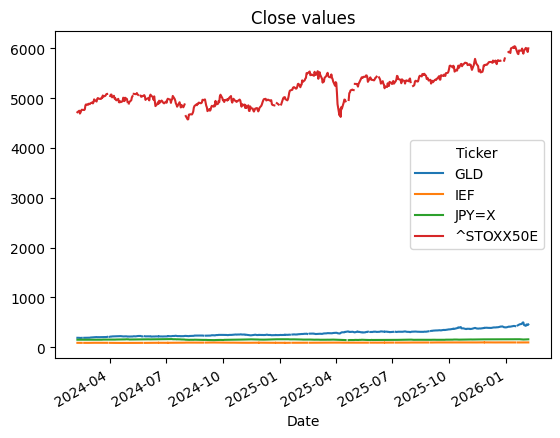

In [ ]:
data = yf.download(tickers=["GLD", "^STOXX50E", "JPY=X", "IEF"], start="2024-02-09", end="2026-02-09")
#Again, we compare the values of 2 years while plotting the graph to visualize it
data['Close'].plot(title="Close values")
#pct_change is a function that calculates the daily percentage returns for each asset
# it works with this formula - return(day(t)) = (price(day(t)) - price(day(t-1)))/price(day(t-1))
#The first value is always NaN because it has no value to be compared to
print(data['Close'].pct_change())
simplified_returns = data['Close'].pct_change()

#We can also use the numpy library function of np.log.diff for this
#Log returns are highly favored in algorithmic trading, risk management, and statistical modeling because they are time-additive.
print(np.log(data['Close']).diff())
log_returns = np.log(data['Close']).diff()


In [4]:
#Since we have combined a few different stock exchanges which work in different timezones, 
# the chances of finding missing or NaN values is high
#Hence we will have to apply a few data cleaning mechanisms to increase the quality of our data.
#Moreover, the vast difference in the charts is because a European index in thousands of points vs. a $95 bond ETF vs. a ~150 FX quote
#Lets move onto fixing these
print(data.isnull().sum())
#As we can see, the data has a few missing values in it - now the question arises on whether we drop the data or fill it,
#and if we do fill it, what values must we fill it with

#As we know that the null or missing values occur on holidays - 
# when the market is closed, we can fill the missing values with the previously registered value using forward fill
# we can also use the bfill to ensure no starting values are missing
# be careful while using the inplace operation as it a permanent change
data = data.ffill().bfill()

Price   Ticker   
Close   GLD          17
        IEF          17
        JPY=X         1
        ^STOXX50E    20
High    GLD          17
        IEF          17
        JPY=X         1
        ^STOXX50E    20
Low     GLD          17
        IEF          17
        JPY=X         1
        ^STOXX50E    20
Open    GLD          17
        IEF          17
        JPY=X         1
        ^STOXX50E    20
Volume  GLD          17
        IEF          17
        JPY=X         1
        ^STOXX50E    20
dtype: int64


Ticker           GLD       IEF     JPY=X  ^STOXX50E
Date                                               
2024-02-09  1.000000  1.000000  1.000000   1.000000
2024-02-12  0.997388  1.000952  0.999384   1.006463
2024-02-13  0.983635  0.989946  1.000978   0.994362
2024-02-14  0.983049  0.993650  1.009815   0.998590
2024-02-15  0.989659  0.996402  1.008609   1.005789
...              ...       ...       ...        ...
2026-02-02  2.276812  1.087732  1.039817   1.273892
2026-02-03  2.421588  1.088758  1.041431   1.271314
2026-02-04  2.419883  1.088530  1.043816   1.266038
2026-02-05  2.355437  1.094912  1.051307   1.256544
2026-02-06  2.427825  1.094912  1.050416   1.271960

[517 rows x 4 columns]


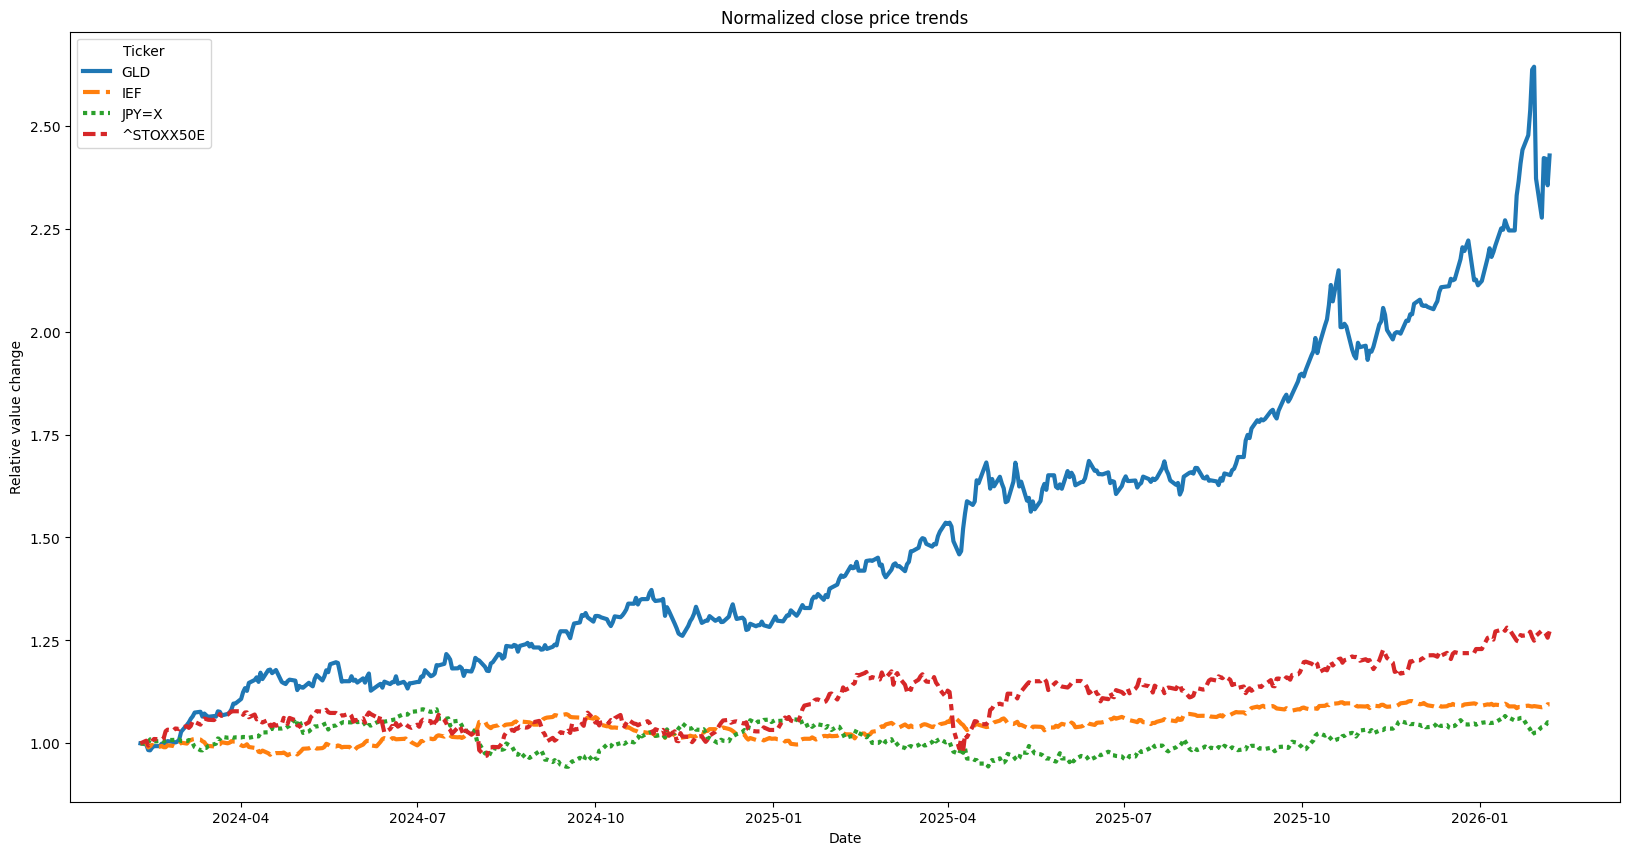

In [5]:
# now we address the problem of normalizing the data - standardizing the values against which prices are held
# We can use the formula - new_prices = current_price/current_price.iloc[0]
# This brings all the data to start at 1.0
close_cleaned = data['Close']
normalized_data = close_cleaned/close_cleaned.iloc[0]
print(normalized_data)
#Lets see the new graph
plt.figure(figsize=(20,10))
sns.lineplot(data=normalized_data, linewidth=3)
plt.title("Normalized close price trends")
plt.xlabel("Date")
plt.ylabel("Relative value change")
plt.show()
#the graph is much cleaner now
#for a correlation heatmap, an ideal number of factors would range from 6 to 10, this is just an example of a project

In [6]:
#One thing worth noting is that, the normalization has no effect on correlation,
# this is because correlation is scale independent
# the normalization was done only for visualization purposes
# it has no relation to the coming learning whatsoever

<Axes: xlabel='Ticker', ylabel='Ticker'>

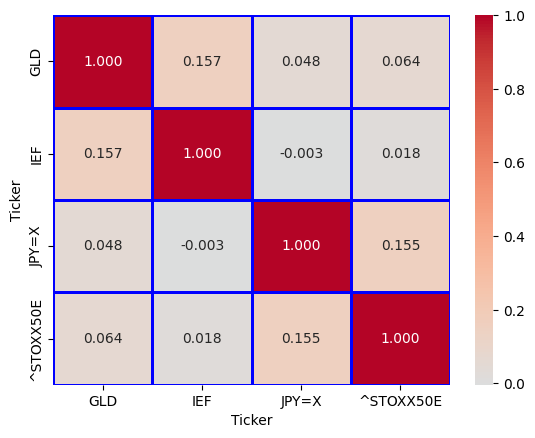

In [7]:
sns.heatmap(data=simplified_returns.corr(), annot=True, fmt='.3f', linewidths=.8,linecolor='blue',center=0,cmap='coolwarm')
#annot is used to show the values of the correlation on the boxes
# whereas format is used to show the number of decimal places
# we can use linewidth to add lines between boxes to make it look cleaner
#From the above heatmap, we can see that the strongest possible relation is between IEF and GLD


<Axes: xlabel='Ticker', ylabel='Ticker'>

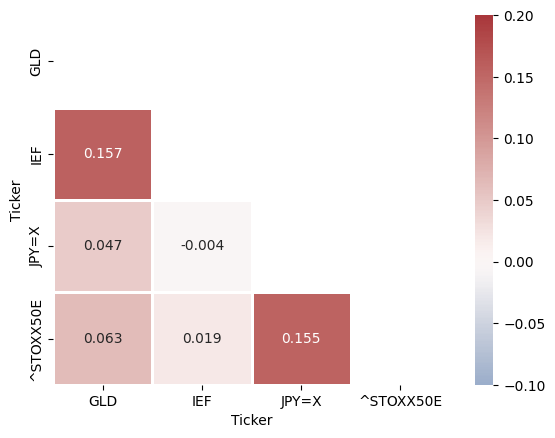

In [8]:
#sns.heatmap(log_returns.corr(), annot=True, fmt='.3f', linewidths=.8, linecolor='white',center=0, cmap='vlag')
#the problem right now is the color grading is not enough to differentiate visually between 0.157 and 0.047 despite their difference
# to solve this we can use mask to hide the upper triangular part of the heatmap 
# or set vmax and vmin to different values
mask = np.triu(np.ones_like(log_returns.corr(), dtype=bool))
sns.heatmap(log_returns.corr(), annot=True, fmt='.3f', linewidths=.8, linecolor='white',center=0, cmap='vlag', mask=mask, vmin=-0.1, vmax=0.2)
# lets expand the heatmap by adding a few more factors to make the heatmap more meaningful

In [13]:
gspc = yf.Ticker("^GSPC")
oil = yf.Ticker("CL=F")
nikki = yf.Ticker("^N225")
copper = yf.Ticker("CPER")
#Following the same process of cleaning and downloading the data
final_data = yf.download(tickers=["^GSPC", "CL=F", "^N225", "CPER", "GLD", "IEF", "JPY=X", "^STOXX50E"])
final_data.ffill(inplace=True)
final_data.bfill(inplace=True)
final_data.isnull().sum()


[*********************100%***********************]  8 of 8 completed


Price   Ticker   
Close   CL=F         0
        CPER         0
        GLD          0
        IEF          0
        JPY=X        0
        ^GSPC        0
        ^N225        0
        ^STOXX50E    0
High    CL=F         0
        CPER         0
        GLD          0
        IEF          0
        JPY=X        0
        ^GSPC        0
        ^N225        0
        ^STOXX50E    0
Low     CL=F         0
        CPER         0
        GLD          0
        IEF          0
        JPY=X        0
        ^GSPC        0
        ^N225        0
        ^STOXX50E    0
Open    CL=F         0
        CPER         0
        GLD          0
        IEF          0
        JPY=X        0
        ^GSPC        0
        ^N225        0
        ^STOXX50E    0
Volume  CL=F         0
        CPER         0
        GLD          0
        IEF          0
        JPY=X        0
        ^GSPC        0
        ^N225        0
        ^STOXX50E    0
dtype: int64

Ticker          CL=F      CPER       GLD       IEF     JPY=X     ^GSPC  \
Date                                                                     
2026-05-05  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000   
2026-05-06  1.000000  1.000000  1.000000  1.000000  1.003073  1.000000   
2026-05-07  0.997160  0.994939  1.001671  0.996947  0.995636  0.996197   
2026-05-08  1.003576  1.019446  1.006520  0.999579  0.997678  1.004591   
2026-05-11  1.031447  1.049281  1.008562  0.996211  0.997863  1.006479   
2026-05-12  1.074674  1.077251  1.004571  0.992842  1.000235  1.004866   
2026-05-13  1.062474  1.072722  0.998933  0.992842  1.003034  1.010744   
2026-05-14  1.064051  1.066063  0.991298  0.992211  1.004180  1.018482   
2026-05-15  1.108750  1.015983  0.968280  0.984316  1.007558  1.005890   
2026-05-18  1.142827  1.022909  0.970925  0.983895  1.010497  1.005150   
2026-05-19  1.133466  1.002397  0.954845  0.980105  1.010605  0.998437   
2026-05-20  1.033446  1.027437  0.9685

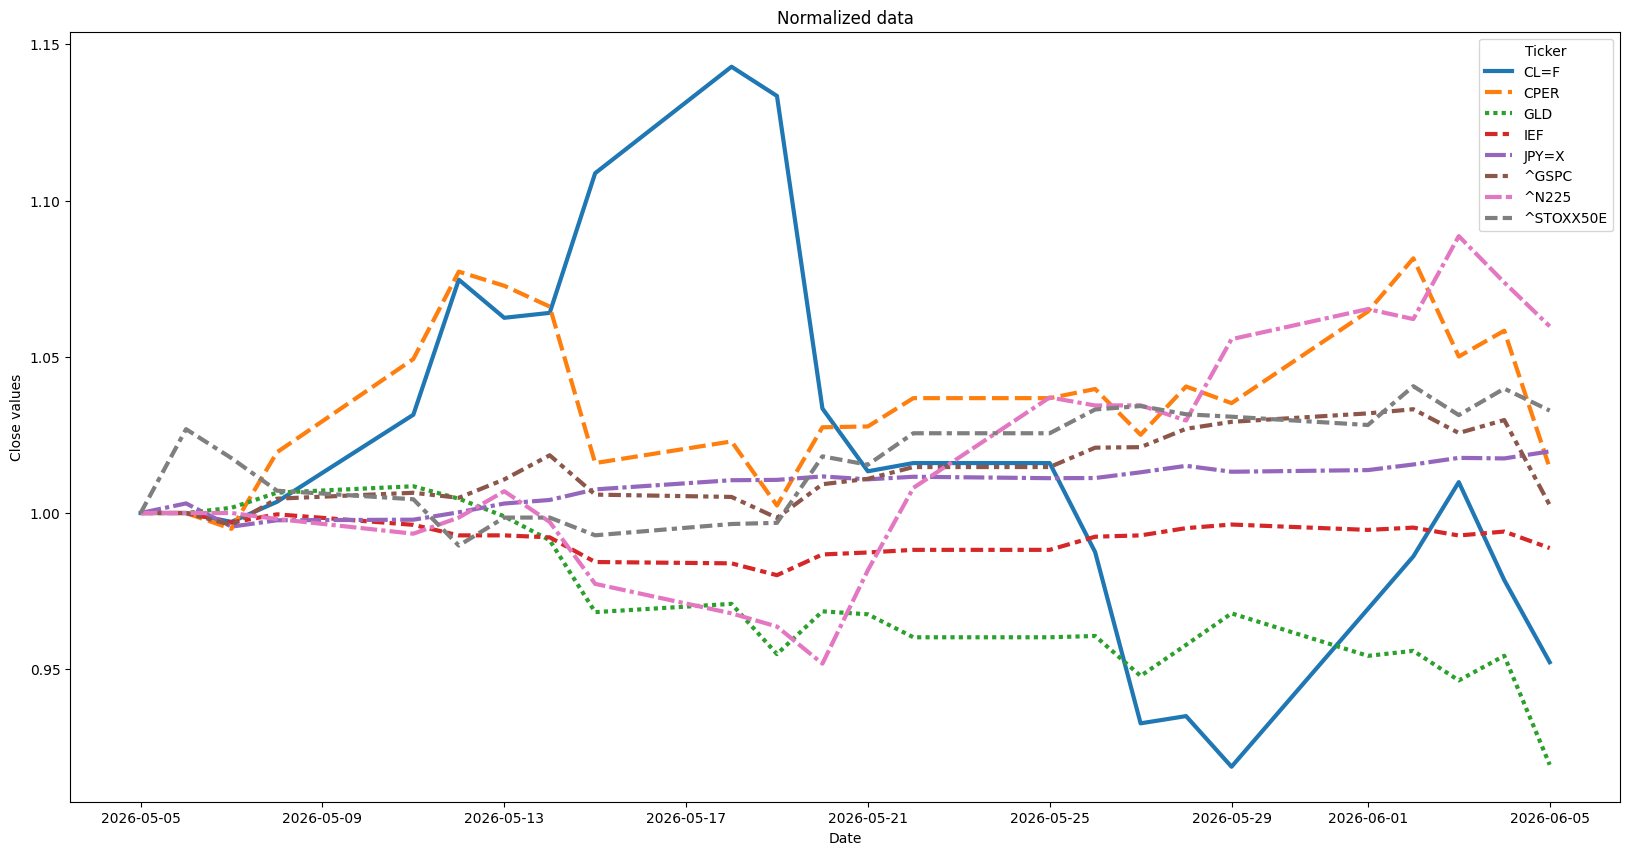

In [18]:
new_closed_data = final_data['Close']
new_normalized = new_closed_data/new_closed_data.iloc[0]
print(new_normalized)
plt.figure(figsize=(20,10))
sns.lineplot(data=new_normalized, linewidth=3)
plt.title("Normalized data")
plt.xlabel("Date")
plt.ylabel("Close values")
plt.show()

In [28]:
#Now lets experiment with rolling correlation - where changes are checked over a period of time
# For now, we take rolling correlation of only 2 commodities to understand its working and syntax
roll_corr = simplified_returns['GLD'].rolling(window=20).corr(simplified_returns['IEF'])
#Before running this code it is important to note that the first window values will always be null,
# this is because window size is used to generate a starting point or data point
print(roll_corr)
# while running this, I ended up getting all null values,
# this was because there was a NULL value in the first 20 rows of data - this breaks the function and returns all null
# after fixing that using ffill & bfill, i get the below accurate output
log_returns.ffill(inplace=True)
log_returns.bfill(inplace=True)
simplified_returns.ffill(inplace=True)
simplified_returns.bfill(inplace=True)

Date
2024-02-09         NaN
2024-02-12         NaN
2024-02-13         NaN
2024-02-14         NaN
2024-02-15         NaN
                ...   
2026-02-02    0.170849
2026-02-03    0.220633
2026-02-04    0.251537
2026-02-05    0.096021
2026-02-06    0.092966
Length: 517, dtype: float64


Ticker,GLD,IEF,JPY=X,^STOXX50E
Date,,,,
2024-02-09,-0.002612,0.000952,-0.000616,0.006463
2024-02-12,-0.002612,0.000952,-0.000616,0.006463
2024-02-13,-0.013789,-0.010996,0.001595,-0.012024
2024-02-14,-0.000596,0.003741,0.008828,0.004252
2024-02-15,0.006724,0.002770,-0.001194,0.007209
...,...,...,...,...
2026-02-02,-0.040049,-0.001966,0.013319,0.010037
2026-02-03,0.063587,0.000943,0.001553,-0.002024
2026-02-04,-0.000704,-0.000209,0.002290,-0.004150


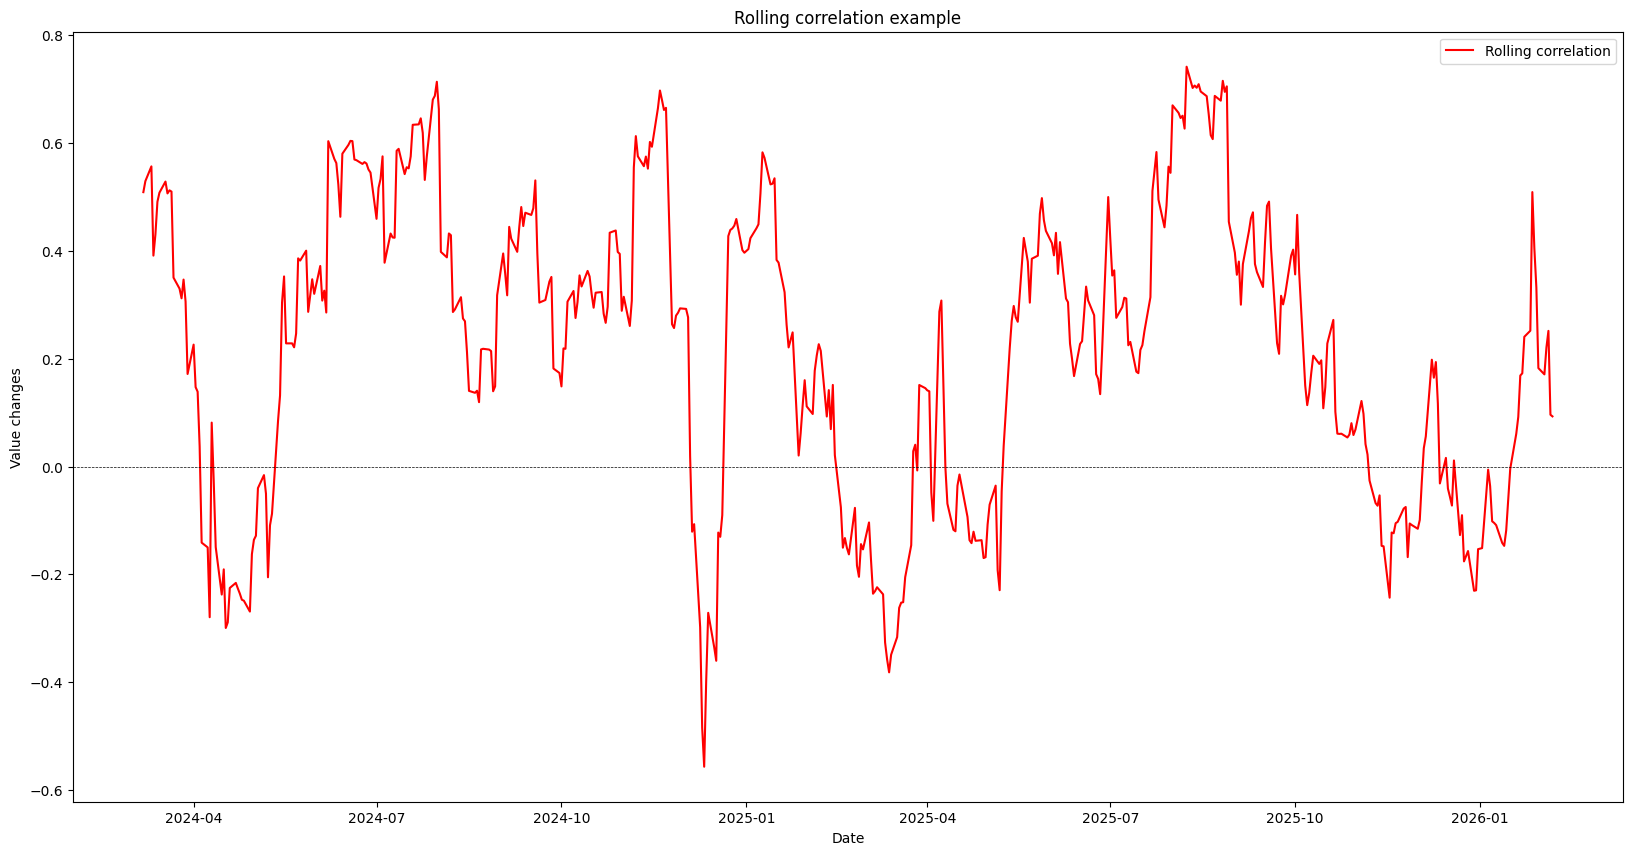

In [31]:
#Now we learn to visualize it
plt.figure(figsize=(20,10))
plt.plot(roll_corr, label='Rolling correlation', color='red')
plt.title("Rolling correlation example")
plt.ylabel("Value changes")
plt.xlabel("Date")
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.legend()
plt.show()

In [ ]:
#We could also use a for loop to printout the exact values of the correlation along with its time period
k=1
for i, j in enumerate(roll_corr):
    if(i>=20):
        print(f"The correlation between the date {k} through date {i+1} is {j}")
        i=0
        k+=1

The correlation between the date 1 through date 21 is 0.5292074458943976
The correlation between the date 2 through date 22 is 0.5565858808094617
The correlation between the date 3 through date 23 is 0.39109999457094224
The correlation between the date 4 through date 24 is 0.43035025347545836
The correlation between the date 5 through date 25 is 0.49098204381321436
The correlation between the date 6 through date 26 is 0.5078141013452547
The correlation between the date 7 through date 27 is 0.5284179441518029
The correlation between the date 8 through date 28 is 0.5064554535802066
The correlation between the date 9 through date 29 is 0.5121490964738151
The correlation between the date 10 through date 30 is 0.5098150396470071
The correlation between the date 11 through date 31 is 0.3502961378937539
The correlation between the date 12 through date 32 is 0.3298702504276684
The correlation between the date 13 through date 33 is 0.3119223989902638
The correlation between the date 14 through 

In [49]:
# Lets do the same process for all of the commodities that we have taken
new_log_returns = np.log(final_data['Close']).diff()
new_log_returns.ffill(inplace = True)
new_log_returns.bfill(inplace = True)
new_log_returns.diff()

all_roll_corr = new_log_returns.rolling(window=20).corr()
all_roll_corr.dropna(inplace=True)

[*********************100%***********************]  8 of 8 completed


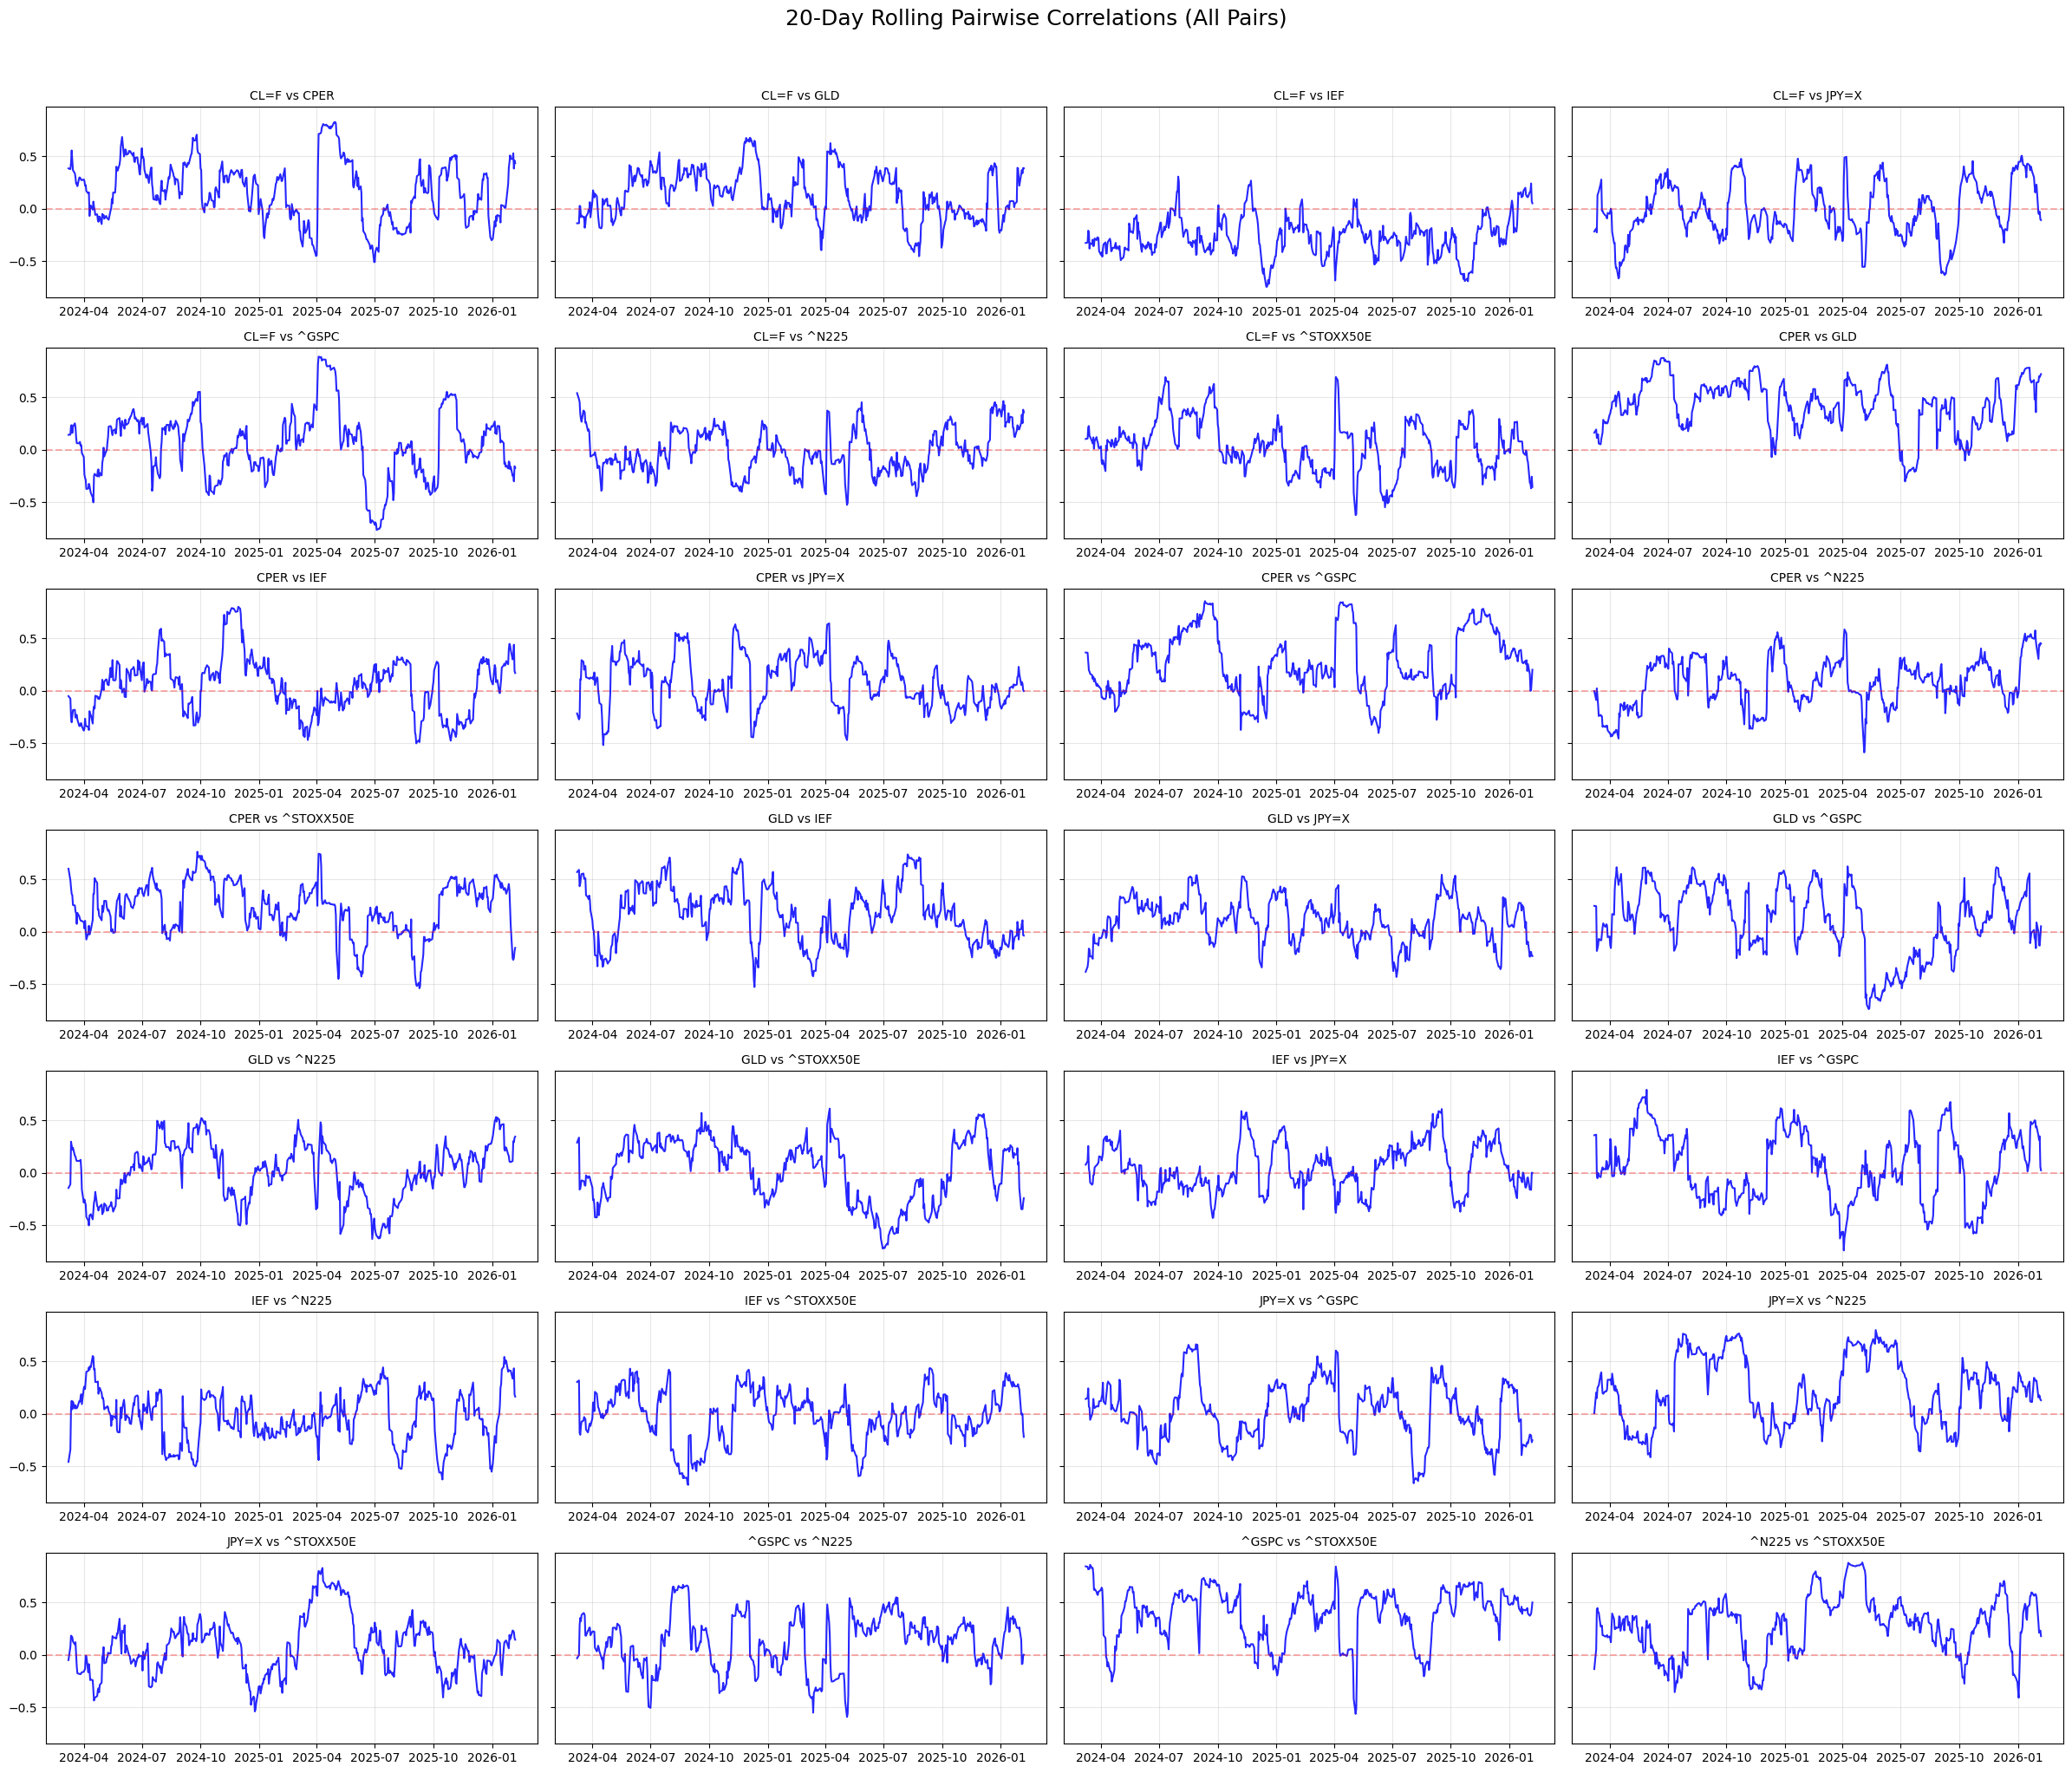

In [ ]:
# now out of this, visualizing for the whole stocks would generate 28 unique lines making the graph unreadable
# to overcome this, we have two methods - 1) a facet grid and 2) an animated heatmap
# our final goal is to build an animated heatmap anyway, but lets try working on a facet grid

# 1. Re-fetch the full 2-year timeline
tickers_list = ["CL=F", "CPER", "GLD", "IEF", "JPY=X", "^GSPC", "^N225", "^STOXX50E"]
raw_data = yf.download(tickers=tickers_list, start="2024-02-09", end="2026-02-09")
close_prices = raw_data['Close'].ffill().bfill()
log_returns = np.log(close_prices).diff().dropna()

#Compute the 20-day rolling correlation matrix
all_roll_corr = log_returns.rolling(window=20).corr().dropna()

#Generate the 28 unique asset pairs
pairs = list(itertools.combinations(log_returns.columns, 2))

#Initialize and plot the 7x4 grid
fig, axes = plt.subplots(7, 4, figsize=(24, 20), sharex=False, sharey=True)
axes = axes.flatten()

for i, (asset1, asset2) in enumerate(pairs):
    ax = axes[i]
    
    try:
        pair_series = all_roll_corr.xs(asset1, level=1)[asset2]
    except KeyError:
        pair_series = all_roll_corr.xs(asset2, level=1)[asset1]
        
    ax.plot(pair_series, color='blue', alpha=0.85, linewidth=1.5)
    ax.axhline(0, color='red', linestyle='--', alpha=0.3)
    ax.set_title(f"{asset1} vs {asset2}", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("20-Day Rolling Pairwise Correlations (All Pairs)", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
#Now lets move on the the final step of making an animated heatmap
